## Procesamiento de Imágenes

**Mejoramiento de la imagen en el espacio**   

## Preparación del entorno

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage import data

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 8
plt.rcParams["figure.autolayout"] = True

## El tríptico {.smaller}

Toda esta sesión se apoya en mirar tres cosas a la vez: la **imagen**, la **curva** $T$ que
se le aplicó, y el **histograma** que resultó. La función siguiente las despliega juntas.

In [2]:
def histograma(img):
    """Cuenta de píxeles por nivel de intensidad, 0 a 255."""
    return np.bincount(img.ravel(), minlength=256)

def triptico(original, transformada, lut, titulo=""):
    """Imagen resultante, curva de transformación y ambos histogramas.

    La curva se dibuja a partir de la LUT: es literalmente la tabla que se aplicó,
    no una reconstrucción teórica de ella.
    """
    fig, ax = plt.subplots(1, 3, figsize=(9.5, 3.1))

    ax[0].imshow(transformada, cmap="gray", vmin=0, vmax=255)
    ax[0].set_title(titulo or "resultado")
    ax[0].axis("off")

    ax[1].plot([0, 255], [0, 255], "--", lw=0.8, color="gray")   # identidad, de referencia
    ax[1].plot(np.arange(256), lut, lw=1.6)
    ax[1].set(xlim=(0, 255), ylim=(0, 255), xlabel="r (entrada)", ylabel="s = T(r)",
              title="función de transformación", aspect="equal")

    ax[2].plot(histograma(original), lw=0.9, alpha=0.55, label="original")
    ax[2].plot(histograma(transformada), lw=0.9, label="transformada")
    ax[2].set(xlim=(0, 255), xlabel="nivel", title="histograma")
    ax[2].legend(fontsize=7)
    plt.show()

def mostrar(imagenes, titulos, filas=1, figsize=None):
    n = len(imagenes)
    cols = int(np.ceil(n / filas))
    fig, axes = plt.subplots(filas, cols, figsize=figsize or (2.9 * cols, 3.1 * filas))
    for ax, im, t in zip(np.atleast_1d(axes).ravel(), imagenes, titulos):
        ax.imshow(im, cmap=None if im.ndim == 3 else "gray",
                  **({} if im.ndim == 3 else dict(vmin=0, vmax=255)))
        ax.set_title(t)
        ax.axis("off")
    for ax in np.atleast_1d(axes).ravel()[n:]:
        ax.axis("off")
    plt.show()

def niveles_usados(img):
    """Cuántos de los 256 niveles posibles aparecen efectivamente en la imagen."""
    return len(np.unique(img))

def entropia(img):
    """Entropía de primer orden en bits/píxel: cuánta información porta el histograma."""
    p = histograma(img).astype(np.float64)
    p = p[p > 0] / img.size
    return -(p * np.log2(p)).sum()

def mostrar_histogramas(histogramas, titulos, filas=1, figsize=None):
    n = len(histogramas)
    cols = int(np.ceil(n / filas))
    fig, axes = plt.subplots(filas, cols, figsize=figsize or (2.9 * cols, 3.1 * filas))
    for ax, h, t in zip(np.atleast_1d(axes).ravel(), histogramas, titulos):
        ax.plot(h, lw=0.9)
        ax.set(xlim=(0, 255), xlabel="nivel", title=t)
    for ax in np.atleast_1d(axes).ravel()[n:]:
        ax.axis("off")
    plt.show()


# Subtema 1 · La función de transformación de intensidad


Una **operación puntual** asigna a cada píxel un nuevo valor que depende únicamente de su valor actual, no de sus vecinos:

$$ s = T(r), \qquad r, s \in [0, L-1], \quad L = 256 $$

Dos consecuencias que conviene fijar de entrada:

- Como $T$ solo depende de $r$, basta calcularla **una vez** para los 256 niveles posibles
  y guardarla en una tabla: una **LUT** (*look-up table*). Aplicarla es indexar.
- La posición de los píxeles es irrelevante, por eso natural para razonar sobre estas operaciones.

El caso más simple es el **negativo**, una recta de pendiente $-1$:

$$ s = L - 1 - r $$


## Ejercicio 1.1 — El tríptico y el negativo

Construye la LUT del negativo y aplícala a `camera`.

1. Despliega el tríptico: resultado, curva y ambos histogramas.
2. Sin tocar el histograma directamente, ¿qué le pasó?
3. Verifica que aplicar la LUT dos veces devuelve la imagen original.

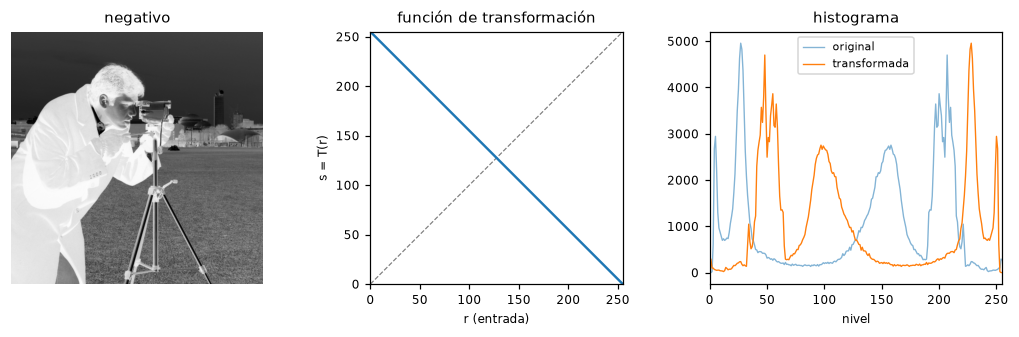

In [3]:
img = data.camera()
r = np.arange(256, dtype=np.uint8)        # Crea todos los niveles posibles de intensidad, 0 a 255
lut_negativo = 255 - r                    # la LUT es la curva T evaluada en los 256 niveles
negativo = lut_negativo[img]              # aplicar = indexar
triptico(img, negativo, lut_negativo, "negativo")

# Verifica que aplicar el LUT dos veces, devuelve exactamente lo mismo.


## Revele la identidad de Mr Negative..

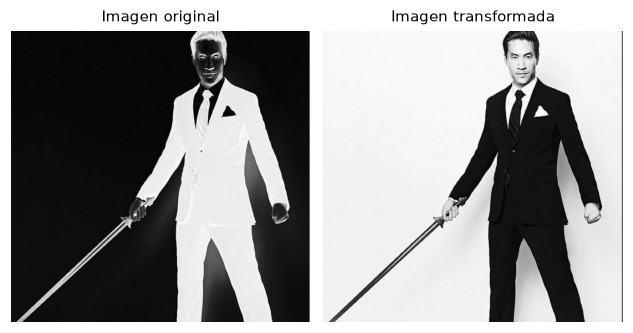

In [12]:
# Su código aqui. Lea la imagen de mr_negative.jpg y aplique la misma transformación. Compare los resultados con la imagen original.
img = cv2.imread("imagenes/mr_negative.jpg", cv2.IMREAD_GRAYSCALE)
# Aplicar la misma transformación que en el código anterior (LUT del negativo)
img_transformed = lut_negativo[img]
mostrar([img, img_transformed], ["Imagen original", "Imagen transformada"], filas=1)

## Ejercicio 1.2 — Lo que el negativo no cambia

Aplica el negativo a `cell`, una imagen de microscopía oscura donde el detalle vive en las
sombras. Mide, en la original y en el negativo:

1. La desviación estándar.
2. El número de niveles efectivamente usados.
3. La entropía de primer orden.

Con esos tres números, responde: ¿el negativo **agrega** algo?

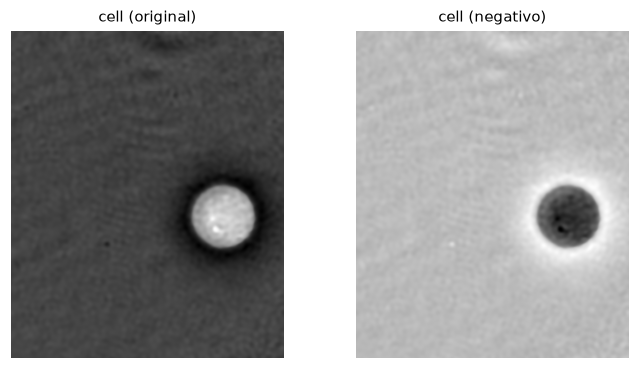

                 std   niveles   entropía
original       23.89       256     5.1333
negativo       23.89       256     5.1333


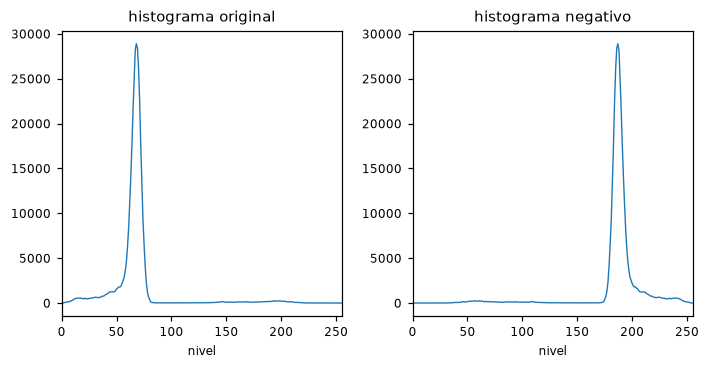

In [13]:
img = data.cell()
negativo = lut_negativo[img]

mostrar([img, negativo], ["cell (original)", "cell (negativo)"], figsize=(6.5, 3.4))


print(f"{'':<12}{'std':>8}{'niveles':>10}{'entropía':>11}")
for nombre, im in [("original", img), ("negativo", negativo)]:
    print(f"{nombre:<12}{im.std():>8.2f}{niveles_usados(im):>10}{entropia(im):>11.4f}")

mostrar_histogramas([histograma(img), histograma(negativo)],
                    ["histograma original", "histograma negativo"], figsize=(6.5, 3.4))

# Subtema 2 · Transformaciones no lineales: gamma

## Cuando una recta no alcanza

Una recta aplica la misma ganancia a todo el rango. Si el detalle está concentrado en las
sombras, expandirlo exige una curva que sea **empinada abajo y plana arriba**. La familia
potencia hace exactamente eso:

$$ s = 255 \cdot \left(\frac{r}{255}\right)^{\gamma} $$

- $\gamma < 1$: expande las sombras, comprime las luces.
- $\gamma > 1$: al revés.
- $\gamma = 1$: identidad.

La regla que conviene retener: **la pendiente local de $T$ es la ganancia de contraste en
ese rango**. Como la pendiente media está acotada, ganar contraste en una zona obliga a
perderlo en otra. 



## Ejercicio 2.1 — Barrido de gamma

Sobre `cell`, aplica $\gamma \in \{0{,}4,\ 0{,}6,\ 1{,}6,\ 2{,}5\}$.

1. Dibuja las cuatro curvas superpuestas.
2. Despliega los cuatro resultados.


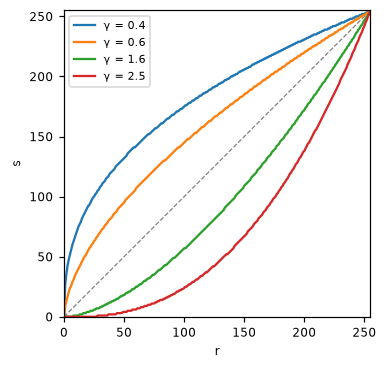

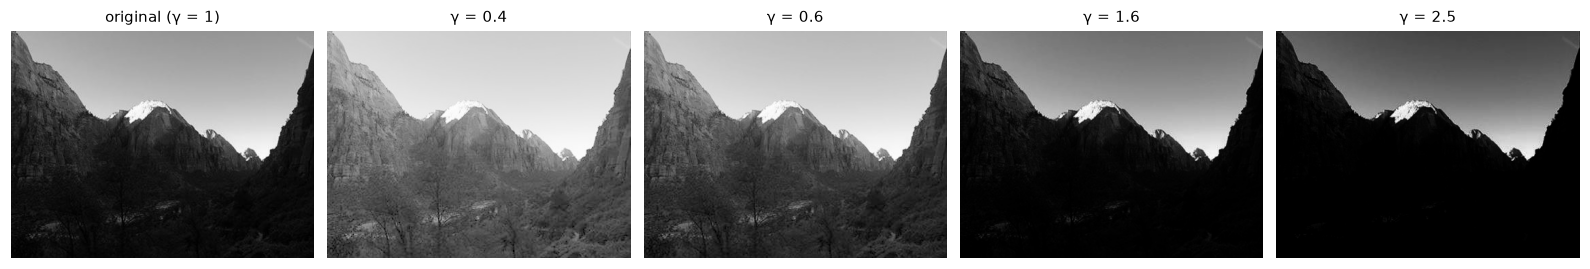

In [26]:
# Lea la imagen y conviertala a RGB
img = cv2.imread("imagenes/volcan.JPG", cv2.IMREAD_GRAYSCALE)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def lut_gamma(g):
    # Se normaliza a [0,1], se eleva a gamma y se vuelve a escalar a [0,255].
    return np.clip(((np.arange(256) / 255.0) ** g) * 255, 0, 255).astype(np.uint8)


gammas = [0.4, 0.6, 1.6, 2.5]
luts = {g: lut_gamma(g) for g in gammas}

plt.figure(figsize=(3.6, 3.4))
plt.plot([0, 255], [0, 255], "--", lw=0.8, color="gray")
for g in gammas:
    plt.plot(np.arange(256), luts[g], lw=1.5, label=f"γ = {g}")
plt.gca().set(xlim=(0, 255), ylim=(0, 255), xlabel="r", ylabel="s", aspect="equal")
plt.legend(fontsize=7)
plt.show()

mostrar([img] + [luts[g][img] for g in gammas],
        ["original (γ = 1)"] + [f"γ = {g}" for g in gammas])


## Ejercicio 2.2 — Gamma frente a la suma de una constante

Supogamos una imagen de bajo contraste. Hay dos formas de aclararla: sumar una constante, o
aplicar $\gamma < 1$. Compáralas usa $+70$ y $\gamma = 0{,}5$.

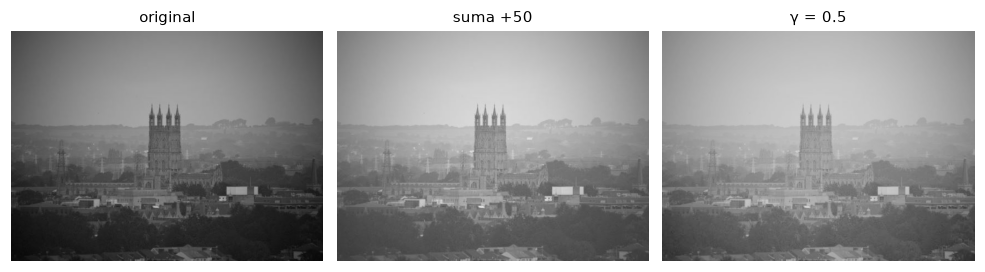

In [16]:
img = cv2.imread("imagenes/torre.JPG")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


suma  = np.clip(img.astype(np.int32) + 50, 0, 255).astype(np.uint8)
gamma = lut_gamma(0.5)[img]

mostrar([img, suma, gamma], ["original", "suma +50", "γ = 0.5"], figsize=(9.0, 3.3))


# Subtema 3 · Estiramiento de contraste y rebanado de niveles

## Estiramiento lineal

Si una imagen ocupa solo el rango $[r_{\min}, r_{\max}]$, la transformación que lo lleva a
$[0, 255]$ es una recta:

$$ s = 255 \cdot \frac{r - r_{\min}}{r_{\max} - r_{\min}} $$

### El problema

$r_{\min}$ y $r_{\max}$ son **estadísticos de orden extremos**: dependen de un solo píxel
cada uno. Basta un punto quemado o un píxel muerto para que el rango medido sea $[0, 255]$
y la transformación se convierta en la identidad.

### La corrección

Reemplazar mínimo y máximo por **percentiles** —típicamente 2 % y 98 %— y recortar lo que
quede fuera. Se sacrifica deliberadamente un 4 % de los píxeles a cambio de que el 96 %
restante ocupe todo el rango.

## Ejercicio 3.1 — Min–max frente a percentiles

Lea una imagen de bajo contraste. Antes de calcular nada, mira su mínimo y su máximo.

1. Aplica estiramiento min–max. Compara el resultado con la original **píxel a píxel**.
2. Aplica estiramiento por percentiles 2–98.
3. Reporta niveles usados en los tres casos y min max

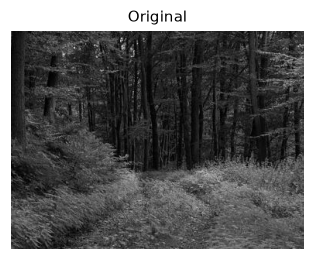

rango medido: [0, 255]   percentiles 2–98: 7–133
píxeles en los extremos (≤5 o ≥250): 1.482%



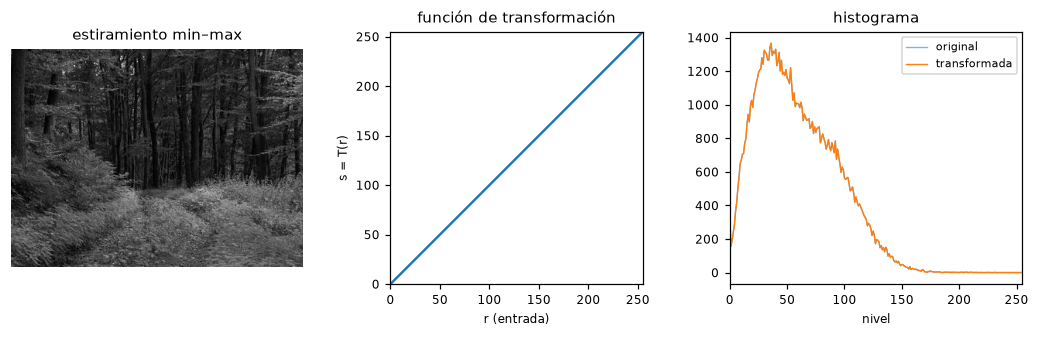

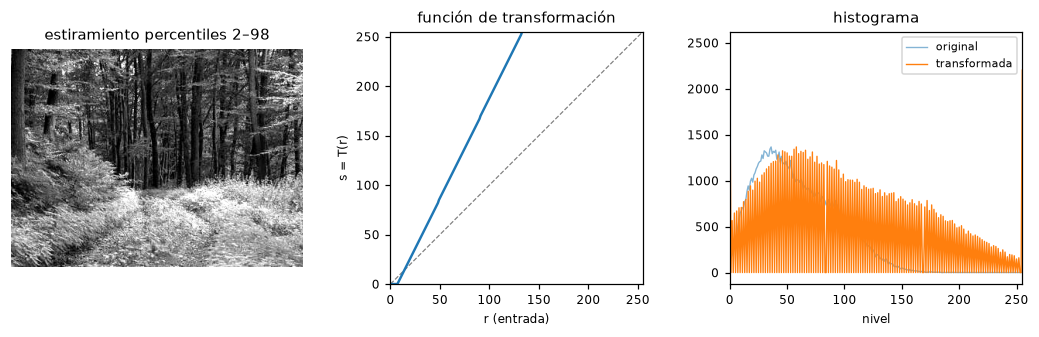

               niveles          rango
original           213(np.uint8(0), np.uint8(255))
min–max            213(np.uint8(0), np.uint8(255))
percentiles        127(np.uint8(0), np.uint8(255))


In [32]:
img = cv2.imread("imagenes/forest.jpg", cv2.IMREAD_GRAYSCALE)
# La imagen ya fue cargada en escala de grises, por lo que no tiene canal de color.
# No es necesario invertir canales.
mostrar([img], ["Original"])
print(f"rango medido: [{img.min()}, {img.max()}]   percentiles 2–98: "
      f"{np.percentile(img, 2):.0f}–{np.percentile(img, 98):.0f}")
print(f"píxeles en los extremos (≤5 o ≥250): {((img <= 5) | (img >= 250)).mean():.3%}\n")

def lut_estiramiento(lo, hi):
    """Recta que lleva [lo, hi] a [0, 255], con recorte fuera de ese intervalo."""
    return np.clip((np.arange(256) - lo) * 255.0 / (hi - lo), 0, 255).astype(np.uint8)

lut_mm = lut_estiramiento(img.min(), img.max())
lut_pc = lut_estiramiento(*np.percentile(img, [2, 98]))

min_max    = lut_mm[img]
percentiles = lut_pc[img]

triptico(img, min_max, lut_mm, "estiramiento min–max")
triptico(img, percentiles, lut_pc, "estiramiento percentiles 2–98")

# Print los niveles usados y rango de intensidad de cada imagen
print(f"{'':<12}{'niveles':>10}{'rango':>15}")
for nombre, im in [("original", img), ("min–max", min_max), ("percentiles", percentiles)]:
    print(f"{nombre:<12}{niveles_usados(im):>10}{str((im.min(), im.max())):>15}")

## Ejercicio 3.2 — Rebanado de niveles de intensidad

Hasta aquí $T$ ha sido monótona. No tiene por qué serlo. El **rebanado** resalta un rango
$[a, b]$ y trata el resto aparte.


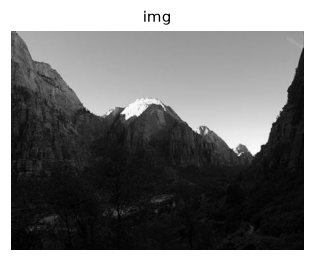

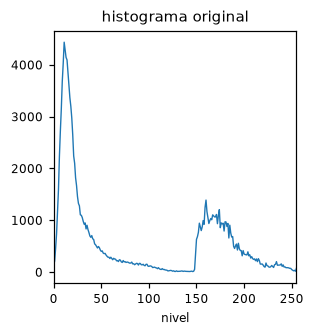

In [33]:
img = cv2.imread("imagenes/volcan.JPG", cv2.IMREAD_GRAYSCALE)
mostrar([img], ["img"])
hist = histograma(img)
mostrar_histogramas([hist], ["histograma original"])

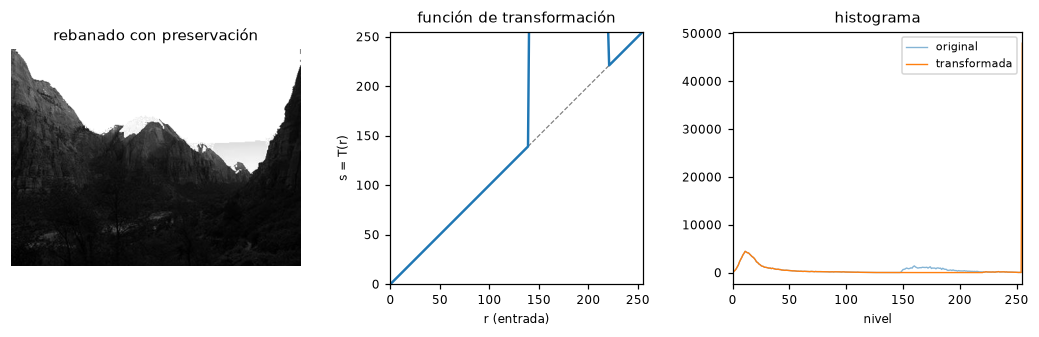

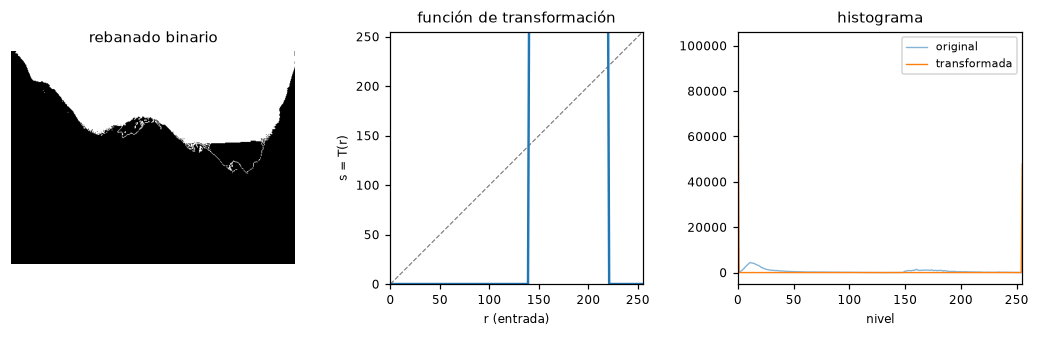

In [34]:
a, b = 140, 220
r = np.arange(256)
dentro = (r >= a) & (r <= b)

lut_preserva = np.where(dentro, 255, r).astype(np.uint8)   # fuera: identidad
lut_binaria  = np.where(dentro, 255, 0).astype(np.uint8)   # fuera: cero

triptico(img, lut_preserva[img], lut_preserva, "rebanado con preservación")
triptico(img, lut_binaria[img],  lut_binaria,  "rebanado binario")

# Subtema 4 · Ecualización de histograma

## De la meta a la curva

La meta natural es un histograma **uniforme**: todos los niveles igualmente poblados, es
decir, ningún rango del rango dinámico desperdiciado.

La $T$ que lo consigue es la **función de distribución acumulada** del propio histograma,
escalada a $[0, 255]$:

$$ s = T(r) = 255 \cdot \sum_{k=0}^{r} p(k), \qquad p(k) = \frac{h(k)}{N} $$

La intuición: donde el histograma está poblado, la acumulada sube rápido y $T$ es empinada
—expande—; donde está vacío, $T$ es plana —comprime—. La curva se adapta sola al contenido
de la imagen. Por eso la ecualización no tiene parámetros.

`np.cumsum(histograma(img))` · `cv2.equalizeHist(img)`

## Ejercicio 4.1 — Implementarla a mano

Ecualiza `moon` sin usar la función de biblioteca, y recién después compárate con ella.

1. Calcula el histograma, su acumulada, y la LUT según la fórmula.
2. Aplícala y despliega el tríptico.
3.  `cv2.equalizeHist` es la función directa de cv2

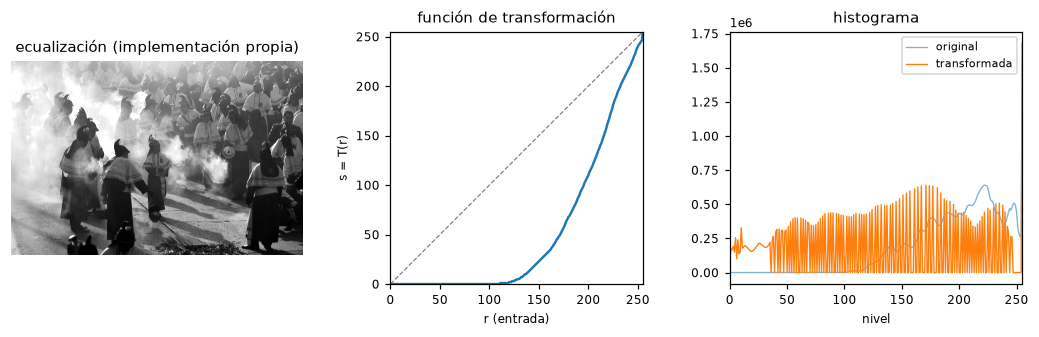

In [35]:
img = cv2.imread("imagenes/people.JPG")

h = histograma(img).astype(np.float64)
cdf = h.cumsum() / img.size                       # acumulada normalizada a [0, 1]
lut_eq = np.round(255 * cdf).astype(np.uint8)     # la fórmula, literal

ecualizada = lut_eq[img]
triptico(img, ecualizada, lut_eq, "ecualización (implementación propia)")


**Nota:** El histograma tranformado se ve asi como con ruido ya que tenemos varios niveles de intensidad. O sea hay hartos saltos de intensidad y cuando las anotamos en el histograma este se va a 0.

## Adelanto: el canal de luminancia

El ejercicio siguiente necesita una idea que aún no hemos cubierto formalmente. Lo mínimo
para poder hacerlo:

Una imagen en color tiene tres canales, R, G y B, que **no** son independientes: los tres
crecen y decrecen juntos con la iluminación de la escena. Existe una transformación lineal
e invertible que separa esa parte común en un solo canal, la **luminancia** $Y$, dejando los
otros dos como diferencias de color:

$$ Y = 0{,}299R + 0{,}587G + 0{,}114B $$

Los tres canales resultantes se llaman $Y$, $C_b$ y $C_r$. Nos basta saber que $Y$ concentra
la información de intensidad y que la conversión no pierde nada.

`cv2.cvtColor(rgb, cv2.COLOR_RGB2YCrCb)` · `cv2.cvtColor(ycc, cv2.COLOR_YCrCb2RGB)`

## Ejercicio 4.3 — Ecualizar una imagen en color

Ecualiza `coffee` de dos maneras:

1. Cada canal R, G y B por separado.
2. Solo el canal $Y$, dejando $C_b$ y $C_r$ intactos.

Mide en ambos casos cuánto se desplazó la crominancia respecto de la original y compara
visualmente.

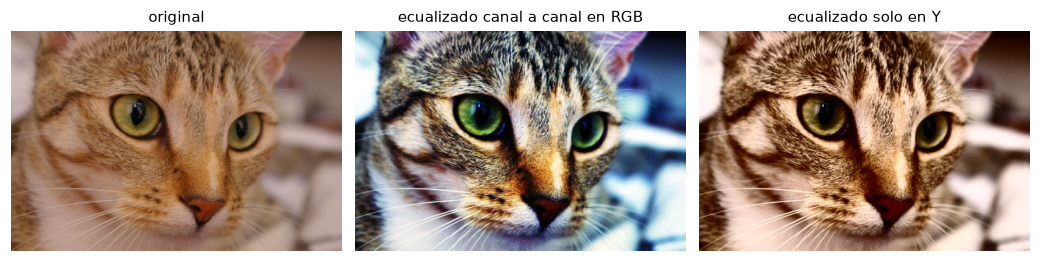

In [36]:
rgb = data.chelsea()
original_ycc = cv2.cvtColor(rgb, cv2.COLOR_RGB2YCrCb).astype(np.float64)

# (1) canal por canal en RGB
eq_rgb = np.stack([cv2.equalizeHist(rgb[..., i]) for i in range(3)], axis=2)

# (2) solo la luminancia
ycc = cv2.cvtColor(rgb, cv2.COLOR_RGB2YCrCb)
ycc[..., 0] = cv2.equalizeHist(ycc[..., 0])
eq_y = cv2.cvtColor(ycc, cv2.COLOR_YCrCb2RGB)

mostrar([rgb, eq_rgb, eq_y],
        ["original", "ecualizado canal a canal en RGB", "ecualizado solo en Y"],
        figsize=(9.5, 3.4))
